# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [7]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [8]:
#Importation du fichier population.csv
population = pd.read_csv('Projet 4/population.csv')

#Importation du fichier dispo_alimentaire.csv
Dispo_alimentaire = pd.read_csv('Projet 4/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
Aide_alimentaire = pd.read_csv('Projet 4/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
Sous_nutrition = pd.read_csv('Projet 4/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [10]:
#Consulter le nombre de colonnes
display(population.columns)
#La nature des données dans chacune des colonnes
display(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
Valeurs_colonnes = population.count()
display(Valeurs_colonnes)

Index(['Zone', 'Année', 'Valeur'], dtype='object')

Zone       object
Année       int64
Valeur    float64
dtype: object

Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [11]:
#Affichage les 5 premières lignes de la table
population.head(5)


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [12]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur']*1000
population


,Zone,Année,Valeur
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0
...,...,...,...
1411,Zimbabwe,2014,13586707.0
1412,Zimbabwe,2015,13814629.0
1413,Zimbabwe,2016,14030331.0
1414,Zimbabwe,2017,14236595.0


In [13]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur':'Population'},inplace=True)


In [14]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(Dispo_alimentaire.shape[0]))

Le tableau comporte 15605 observation(s) ou article(s)


In [16]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(Dispo_alimentaire.shape[1]))

Le tableau comporte 18 colonne(s)


In [17]:
#Affichage les 5 premières lignes de la table
Dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [18]:
#remplacement des NaN dans le dataset par des 0
Dispo_alimentaire.fillna(0,inplace=True)
Dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [19]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
Colonnes_a_convertir = ["Aliments pour animaux","Autres Utilisations","Disponibilité intérieure","Exportations - Quantité","Importations - Quantité","Nourriture","Pertes","Production","Semences","Traitement","Variation de stock"]
for Colonne in Colonnes_a_convertir:
    Dispo_alimentaire[Colonne]=Dispo_alimentaire[Colonne]*1000

In [20]:
#Affichage les 5 premières lignes de la table
Dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(Aide_alimentaire.shape[0]))

Le tableau comporte 1475 observation(s) ou article(s)


In [22]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(Aide_alimentaire.shape[1]))

Le tableau comporte 4 colonne(s)


In [23]:
#Affichage les 5 premières lignes de la table
Aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [24]:
#changement du nom de la colonne Pays bénéficiaire par Zone
Aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'},inplace=True)

In [25]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
Aide_alimentaire['Valeur']=Aide_alimentaire['Valeur']*1000

In [26]:
#Affichage les 5 premières lignes de la table
Aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [27]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(Sous_nutrition.shape[0]))

Le tableau comporte 1218 observation(s) ou article(s)


In [28]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(Sous_nutrition.shape[1]))

Le tableau comporte 3 colonne(s)


In [29]:
#Afficher les 5 premières lignes de la table
Sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [30]:
#Conversion de la colonne sous nutrition en numérique
Sous_nutrition['Valeur'] = pd.to_numeric(Sous_nutrition["Valeur"],errors='coerce')
Sous_nutrition['Valeur'] = Sous_nutrition['Valeur'].fillna(0)

#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0


In [31]:
#changement du nom de la colonne Valeur par sous_nutrition
Sous_nutrition.rename(columns={'Valeur':'sous_nutrition'},inplace=True)



In [32]:
#Multiplication de la colonne sous_nutrition par 1000000
Sous_nutrition['sous_nutrition']=Sous_nutrition['sous_nutrition']*1000000

In [33]:
#Afficher les 5 premières lignes de la table
Sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [34]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# filtrer sur l'année 2017 puis lier la jointure
Pop_2017 = population.loc[population['Année'] ==2017]
Pop_2017 = Pop_2017.drop(columns = 'Année')
SS_nut_2017 = Sous_nutrition.loc[Sous_nutrition['Année'] =='2016-2018']
SS_nut_2017 = SS_nut_2017.drop(columns = 'Année')
Data_nutrition_2017 = pd.merge(Pop_2017,SS_nut_2017,on ='Zone')
display(Data_nutrition_2017)

,Zone,Population,sous_nutrition
0,Afghanistan,36296113.0,10500000.0
1,Afrique du Sud,57009756.0,3100000.0
2,Albanie,2884169.0,100000.0
3,Algérie,41389189.0,1300000.0
4,Allemagne,82658409.0,0.0
...,...,...,...
198,Venezuela (République bolivarienne du),29402484.0,8000000.0
199,Viet Nam,94600648.0,6500000.0
200,Yémen,27834819.0,0.0
201,Zambie,16853599.0,0.0


In [35]:
#Affichage du dataset
Data_nutrition_2017.shape

(203, 3)

In [36]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
Nb_pers_ss_nut = Data_nutrition_2017['sous_nutrition'].sum()
print (Nb_pers_ss_nut)


535700000.0


In [37]:
# prendre le nombre de personnes en sous nutr, 2 colonnes résultats => % total nutr/population
Pop_total = Data_nutrition_2017['Population'].sum()
print (Pop_total)
Ratio_sous_nut_total =(Nb_pers_ss_nut/Pop_total)*100
print(Ratio_sous_nut_total)


7543798779.0
7.1011968332354165


([<matplotlib.patches.Wedge at 0x1d8e5499910>,
 [Text(1.0727492911231424, 0.24332890990343878, 'Sous nutrition'),
  Text(-1.0727492740365672, -0.24332898523196622, 'Population mondiale')],
 [Text(0.5851359769762594, 0.13272485994733021, '7.10%'),
  Text(-0.5851359676563093, -0.13272490103561793, '92.90%')])

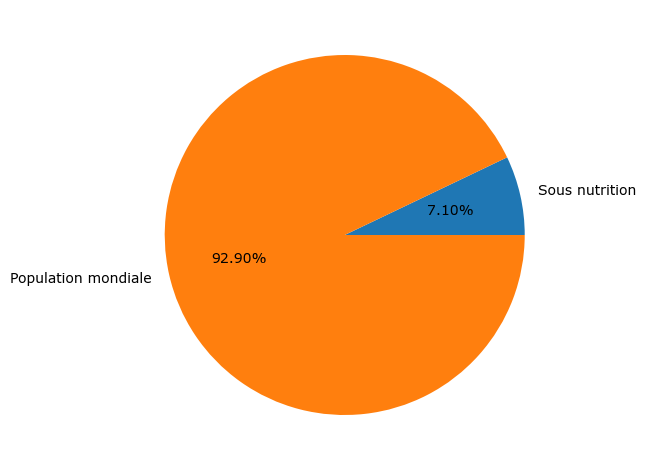

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
Data_ssnutrionvspoptotal = [7.10,92.9]
labels = ['Sous nutrition','Population mondiale']
plt.pie(Data_ssnutrionvspoptotal, labels= labels,autopct='%2.2f%%')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [39]:
#Combien mange en moyenne un être humain ? Source => Besoin Kcal par jour 2400kcal Source => 
#https://nutriandco.com/fr/pages/calcul-apport-calorique-journalier#:~:text=Ce%20qu%27il%20faut%20retenir%20%3A%201%20Officiellement%2C%202100,du%20poids%20%3A%20votre%20poids%20actuel%20x%2025
Besoin_Kcal_jour_pers = 2400

In [40]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
Personne_nourries = pd.merge(Pop_2017,Dispo_alimentaire,on ='Zone')


In [41]:
#Affichage du nouveau dataframe
display(Personne_nourries)

,Zone,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,0.83,37000.0,0.0,6000.0,37000.0,0.0,32000.0,0.0,0.0,0.0
15412,Zimbabwe,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,1.69,70000.0,0.0,6000.0,70000.0,0.0,64000.0,0.0,0.0,0.0
15413,Zimbabwe,14236595.0,"Viande, Autre",animale,0.0,1000.0,7.0,2.29,0.21,1.12,34000.0,3000.0,1000.0,32000.0,0.0,36000.0,0.0,0.0,0.0
15414,Zimbabwe,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,0.00,4000.0,0.0,2000.0,4000.0,0.0,2000.0,0.0,0.0,0.0


In [42]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_kcal = Personne_nourries.groupby(['Zone']).agg({'Disponibilité alimentaire (Kcal/personne/jour)':'sum','Population':'max'})
display(dispo_kcal)

,Disponibilité alimentaire (Kcal/personne/jour),Population
Zone,,
Afghanistan,2087.0,36296113.0
Afrique du Sud,3020.0,57009756.0
Albanie,3188.0,2884169.0
Algérie,3293.0,41389189.0
Allemagne,3503.0,82658409.0
...,...,...
Émirats arabes unis,3275.0,9487203.0
Équateur,2346.0,16785361.0
États-Unis d'Amérique,3682.0,325084756.0


In [43]:
#Calcul du nombre d'humains pouvant être nourris
dispo_kcal ['Dispo_Kcal_jour'] =  dispo_kcal['Disponibilité alimentaire (Kcal/personne/jour)']	* dispo_kcal['Population']
dispo_kcal ['nb_pers_nourries_jour'] =  dispo_kcal['Dispo_Kcal_jour']/Besoin_Kcal_jour_pers
display(dispo_kcal)
Nb_pers_nourries_total_jour = dispo_kcal['nb_pers_nourries_jour'].sum()
print("le nombre de personnes pouvant être nourries au niveau mondial est de", Nb_pers_nourries_total_jour)

,Disponibilité alimentaire (Kcal/personne/jour),Population,Dispo_Kcal_jour,nb_pers_nourries_jour
Zone,,,,
Afghanistan,2087.0,36296113.0,7.574999e+10,3.156249e+07
Afrique du Sud,3020.0,57009756.0,1.721695e+11,7.173728e+07
Albanie,3188.0,2884169.0,9.194731e+09,3.831138e+06
Algérie,3293.0,41389189.0,1.362946e+11,5.678942e+07
Allemagne,3503.0,82658409.0,2.895524e+11,1.206468e+08
...,...,...,...,...
Émirats arabes unis,3275.0,9487203.0,3.107059e+10,1.294608e+07
Équateur,2346.0,16785361.0,3.937846e+10,1.640769e+07
États-Unis d'Amérique,3682.0,325084756.0,1.196962e+12,4.987342e+08


le nombre de personnes pouvant être nourries au niveau mondial est de 8716243594.72125


In [44]:
#Population totale en 2017
Pop_total_mondial_2017 = 7500000000
Ratio_pop_tot_sur_nourrissble_2017 =  (Nb_pers_nourries_total_jour/Pop_total_mondial_2017)*100
print(Ratio_pop_tot_sur_nourrissble_2017 )

116.21658126295


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [45]:
#Transfert des données avec les végétaux dans un nouveau dataframe
Personne_nourries_veg = Personne_nourries.loc[Personne_nourries['Origine']=='vegetale']
display(Personne_nourries_veg)

,Zone,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
1,Afghanistan,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0
6,Afghanistan,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000.0,0.0,3000.0,3000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Zimbabwe,14236595.0,Sésame,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15407,Zimbabwe,14236595.0,Thé,vegetale,0.0,0.0,1.0,0.54,0.00,0.15,8000.0,12000.0,1000.0,8000.0,0.0,19000.0,0.0,0.0,0.0
15408,Zimbabwe,14236595.0,Tomates,vegetale,0.0,0.0,1.0,1.80,0.01,0.04,27000.0,0.0,3000.0,25000.0,1000.0,24000.0,0.0,0.0,0.0
15414,Zimbabwe,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,0.00,4000.0,0.0,2000.0,4000.0,0.0,2000.0,0.0,0.0,0.0


In [46]:
#Calcul du nombre de kcal disponible pour les végétaux
dispo_kcal_veg = Personne_nourries_veg.groupby(['Zone']).agg({'Disponibilité alimentaire (Kcal/personne/jour)':'sum','Population':'max'})
display(dispo_kcal_veg)

,Disponibilité alimentaire (Kcal/personne/jour),Population
Zone,,
Afghanistan,1871.0,36296113.0
Afrique du Sud,2533.0,57009756.0
Albanie,2203.0,2884169.0
Algérie,2915.0,41389189.0
Allemagne,2461.0,82658409.0
...,...,...
Émirats arabes unis,2718.0,9487203.0
Équateur,1732.0,16785361.0
États-Unis d'Amérique,2698.0,325084756.0


In [47]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
dispo_kcal_veg ['Dispo_kcal_jour_veg'] =  dispo_kcal_veg['Disponibilité alimentaire (Kcal/personne/jour)']	* dispo_kcal_veg['Population']
dispo_kcal_veg ['nb_pers_nourries_kcal_veg'] =  dispo_kcal_veg['Dispo_kcal_jour_veg']/Besoin_Kcal_jour_pers
display(dispo_kcal_veg)
Nb_pers_nourries_total_jour_veg = dispo_kcal_veg['nb_pers_nourries_kcal_veg'].sum()
print("le nombre de personnes pouvant être nourries au niveau mondial en produit végétaux est de", Nb_pers_nourries_total_jour_veg)

,Disponibilité alimentaire (Kcal/personne/jour),Population,Dispo_kcal_jour_veg,nb_pers_nourries_kcal_veg
Zone,,,,
Afghanistan,1871.0,36296113.0,6.791003e+10,2.829584e+07
Afrique du Sud,2533.0,57009756.0,1.444057e+11,6.016905e+07
Albanie,2203.0,2884169.0,6.353824e+09,2.647427e+06
Algérie,2915.0,41389189.0,1.206495e+11,5.027062e+07
Allemagne,2461.0,82658409.0,2.034223e+11,8.475931e+07
...,...,...,...,...
Émirats arabes unis,2718.0,9487203.0,2.578622e+10,1.074426e+07
Équateur,1732.0,16785361.0,2.907225e+10,1.211344e+07
États-Unis d'Amérique,2698.0,325084756.0,8.770787e+11,3.654494e+08


le nombre de personnes pouvant être nourries au niveau mondial en produit végétaux est de 7191985088.125416


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [48]:
#Calcul de la disponibilité totale
Dispo_inté_tot = Dispo_alimentaire['Disponibilité intérieure'].sum()
print("la disponibilité totale est", Dispo_inté_tot)

la disponibilité totale est 9848994000.0


In [49]:
display(Dispo_alimentaire)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000.0,0.0,0.0,3000.0,0.0,2000.0,0.0,0.0,0.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
Data_dispo_int = ["Aliments pour animaux","Nourriture","Pertes","Semences","Traitement","Autres Utilisations"]
for Dispo_int in Data_dispo_int:
    print("Proportion pour",Dispo_int,(Dispo_alimentaire[Dispo_int].sum()/Dispo_inté_tot)*100)

Proportion pour Aliments pour animaux 13.242418464261426
Proportion pour Nourriture 49.51021393657058
Proportion pour Pertes 4.606541541196999
Proportion pour Semences 1.5705258831511117
Proportion pour Traitement 22.384895350733284
Proportion pour Autres Utilisations 8.782856401374598


In [51]:
Repartition_dispo_alimentaire = Dispo_alimentaire[['Aliments pour animaux','Nourriture','Pertes','Semences','Traitement','Autres Utilisations']]
Repartition_dispo_alimentaire['Zone'] = 'All'
Repartition_dispo_groupe = Repartition_dispo_alimentaire.groupby(['Zone']).agg({'Aliments pour animaux':'sum','Nourriture':'sum','Pertes':'sum','Semences':'sum','Traitement':'sum','Autres Utilisations':'sum'})
Repartition_dispo_groupe = Repartition_dispo_groupe.reset_index()
df_melt = pd.melt(Repartition_dispo_groupe,id_vars=['Zone'],var_name='repartion',value_name='valeurs')
display(df_melt)


C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\2292461064.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Repartition_dispo_alimentaire['Zone'] = 'All'


,Zone,repartion,valeurs
0,All,Aliments pour animaux,1.304245e+09
1,All,Nourriture,4.876258e+09
2,All,Pertes,4.536980e+08
3,All,Semences,1.546810e+08
4,All,Traitement,2.204687e+09
5,All,Autres Utilisations,8.650230e+08


([<matplotlib.patches.Wedge at 0x1d8e63d1910>,
 [Text(1.0063537450463638, 0.4441307688408431, 'Aliments pour animaux'),
  Text(-0.7999957113477486, 0.754987987868158, 'Nourriture'),
  Text(-0.646979358138829, -0.8896166085130544, 'Pertes'),
  Text(-0.4634678736291093, -0.9975958751487057, 'Semences'),
  Text(0.3428190463756664, -1.0452153373549773, 'Traitement'),
  Text(1.0584724828480327, -0.2993927237818598, 'Autres Utilisations')],
 [Text(0.5489202245707439, 0.24225314664045985, '13.23%'),
  Text(-0.43636129709877197, 0.41181162974626795, '49.46%'),
  Text(-0.35289783171208855, -0.4852454228253023, '4.60%'),
  Text(-0.25280065834315046, -0.5441432046265667, '1.57%'),
  Text(0.18699220711399986, -0.5701174567390784, '22.36%'),
  Text(0.5773486270080178, -0.1633051220628326, '8.77%')])

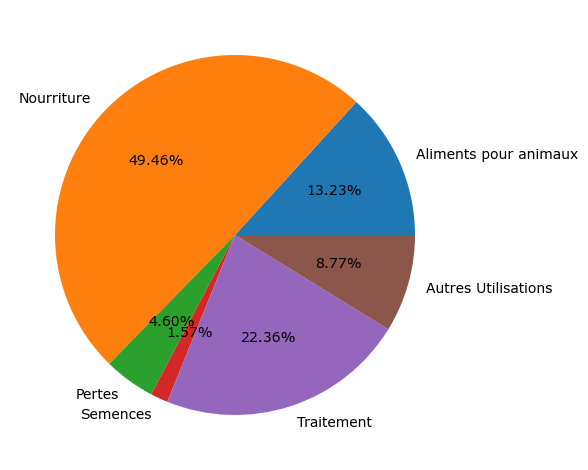

In [52]:
import matplotlib.pyplot as plt
plt.pie(x=df_melt['valeurs'],labels=df_melt['repartion'],autopct='%2.2f%%')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [53]:
#Création d'une liste avec toutes les variables
liste_céréales = ["Blé","Riz (Eq Blanchi)","Orge","Maïs","Seigle","Avoine","Millet","Sorgho","Céréales","Autres"]


In [54]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
Personne_nourries_céréales = Dispo_alimentaire.loc[Dispo_alimentaire['Produit'].isin(liste_céréales)]
display(Personne_nourries_céréales)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5992000.0,0.0,1173000.0,4895000.0,775000.0,5169000.0,322000.0,0.0,-350000.0
32,Afghanistan,Maïs,vegetale,200000.0,0.0,21.0,2.50,0.30,0.56,313000.0,0.0,1000.0,76000.0,31000.0,312000.0,5000.0,0.0,0.0
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,13000.0,0.0,0.0,12000.0,1000.0,13000.0,0.0,0.0,0.0
40,Afghanistan,Orge,vegetale,360000.0,0.0,26.0,2.92,0.24,0.79,524000.0,0.0,10000.0,89000.0,52000.0,514000.0,22000.0,0.0,0.0
47,Afghanistan,Riz (Eq Blanchi),vegetale,0.0,0.0,141.0,13.82,0.27,2.70,461000.0,0.0,119000.0,422000.0,24000.0,342000.0,14000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15537,Îles Salomon,Blé,vegetale,0.0,0.0,184.0,25.37,1.00,5.19,14000.0,0.0,14000.0,14000.0,0.0,0.0,0.0,0.0,0.0
15568,Îles Salomon,Maïs,vegetale,0.0,0.0,1.0,0.15,0.01,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15575,Îles Salomon,Orge,vegetale,0.0,0.0,0.0,0.07,0.00,0.01,1000.0,0.0,1000.0,0.0,0.0,0.0,0.0,1000.0,0.0
15591,Îles Salomon,Riz (Eq Blanchi),vegetale,0.0,12000.0,623.0,63.76,1.36,10.90,49000.0,0.0,47000.0,36000.0,1000.0,3000.0,0.0,0.0,0.0


In [55]:
#Affichage de la proportion d'alimentation animale
Dispo_int_cereale = Personne_nourries_céréales['Disponibilité intérieure'].sum()
Datafram_ble = Personne_nourries_céréales.loc[Personne_nourries_céréales['Produit']=='Blé']#['Disponibilité intérieure'].sum()
Dispo_total_int_blé = Datafram_ble['Disponibilité intérieure'].sum()
Proportion_dispo_int_blé = (Dispo_total_int_blé/Dispo_int_cereale)*100
print(Proportion_dispo_int_blé)

28.556167351820584


In [56]:
Utilisation_pour_animaux = Personne_nourries_céréales['Aliments pour animaux'].sum()
Utilisation_pour_humains = Personne_nourries_céréales['Nourriture'].sum()
Proportion_utilisation_pour_animaux = round((Utilisation_pour_animaux/Dispo_int_cereale)*100,2)
print("la proportion d'alimentation animale",Proportion_utilisation_pour_animaux)
Proportion_utilisation_pour_humains = round((Utilisation_pour_humains/Dispo_int_cereale)*100,2)
print("la proportion d'alimentation humains",Proportion_utilisation_pour_humains)

la proportion d'alimentation animale 35.91
la proportion d'alimentation humains 43.02


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [57]:
#Création de la colonne proportion par pays
Data_nutrition_2017['proportion_pays'] = round(((Data_nutrition_2017['sous_nutrition']/Data_nutrition_2017['Population'])*100),2)

In [58]:
#affichage après trie des 10 pires pays
Liste_10_pays_SS_alimenté_2017 = Data_nutrition_2017.sort_values(['proportion_pays'],ascending=[False]).head(10)
display(Liste_10_pays_SS_alimenté_2017)

,Zone,Population,sous_nutrition,proportion_pays
78,Haïti,10982366.0,5300000.0,48.26
157,République populaire démocratique de Corée,25429825.0,12000000.0,47.19
108,Madagascar,25570512.0,10500000.0,41.06
103,Libéria,4702226.0,1800000.0,38.28
100,Lesotho,2091534.0,800000.0,38.25
183,Tchad,15016753.0,5700000.0,37.96
161,Rwanda,11980961.0,4200000.0,35.06
121,Mozambique,28649018.0,9400000.0,32.81
186,Timor-Leste,1243258.0,400000.0,32.17
0,Afghanistan,36296113.0,10500000.0,28.93


([<matplotlib.patches.Wedge at 0x1d8e676e690>,
 [Text(1.0135890557918668, 0.4273607679454821, 'Haïti'),
  Text(0.41066889098990156, 1.020466100354698, 'République populaire démocratique de Corée'),
  Text(-0.37413712870468835, 1.0344183916214036, 'Madagascar'),
  Text(-0.9274162943189939, 0.5915226259676174, 'Libéria'),
  Text(-1.0976780210951154, -0.07143501945622713, 'Lesotho'),
  Text(-0.8447948741295602, -0.7045009727774836, 'Tchad'),
  Text(-0.2954984782356084, -1.0595662552952694, 'Rwanda'),
  Text(0.31367639468256103, -1.054327804536592, 'Mozambique'),
  Text(0.809068019606483, -0.745257633070634, 'Timor-Leste'),
  Text(1.068682474556796, -0.26061037695219125, 'Afghanistan')],
 [Text(0.5528667577046545, 0.2331058734248084, '12.70%'),
  Text(0.224001213267219, 0.5566178729207443, '12.42%'),
  Text(-0.20407479747528454, 0.5642282136116746, '10.81%'),
  Text(-0.5058634332649057, 0.3226487050732458, '10.07%'),
  Text(-0.598733466051881, -0.038964556067032974, '10.07%'),
  Text(-0.46

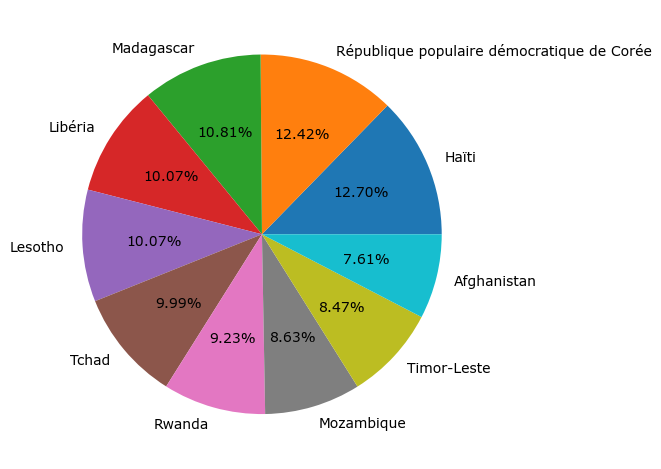

In [59]:
#Graphique des 10 pays ou la proposition de personnes en sous nutrition est la plus forte en 2017
import matplotlib.pyplot as plt
plt.pie(x=Liste_10_pays_SS_alimenté_2017['proportion_pays'],labels=Liste_10_pays_SS_alimenté_2017['Zone'],autopct='%2.2f%%')

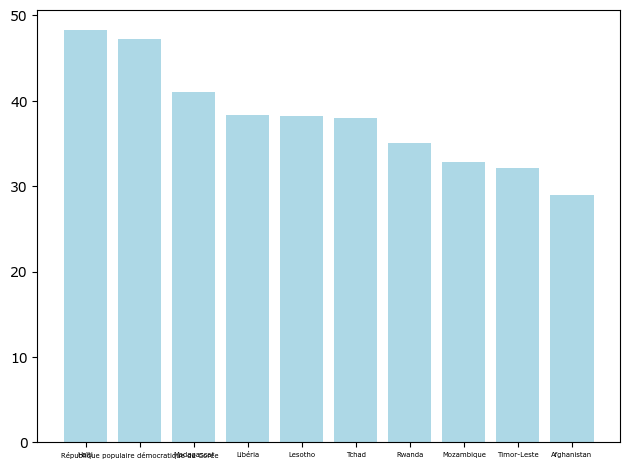

In [60]:
import matplotlib.pyplot as plt
plt.title = ('10 pays ou la proposition de personnes en sous nutrition est la plus forte en 2017')
plt.rcParams.update({'xtick.labelsize':5,})
plt.xlabel= ('Pays')
plt.ylabel= ('la proposition de personnes en sous nutrition')
plt.bar(height = Liste_10_pays_SS_alimenté_2017['proportion_pays'],x=Liste_10_pays_SS_alimenté_2017['Zone'],color='lightblue')
plt.show()

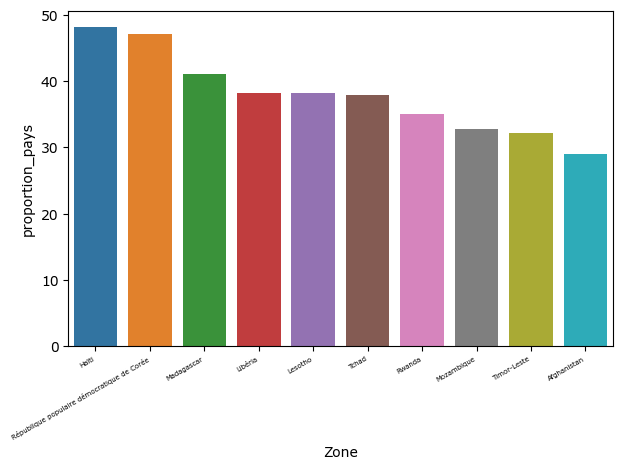

[6.4, 4.8]
large


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data = Liste_10_pays_SS_alimenté_2017,x='Zone',y='proportion_pays')
plt.rcParams.update({'xtick.labelsize':10,})
plt.xticks(rotation=30,ha='right')
plt.title = ('10 pays ou la proposition de personnes en sous nutrition est la plus forte en 2017')
plt.xlabel= ('Pays')
plt.ylabel= ('la proposition de personnes en sous nutrition')
plt.show()
print(plt.rcParams['figure.figsize'])
print(plt.rcParams['figure.titlesize'])

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [62]:
#calcul du total de l'aide alimentaire par pays
Total_aide_aliment_from2013 = Aide_alimentaire.groupby(['Zone']).agg({'Valeur':'sum'})

In [63]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
Liste_10pays_le_plus_aidé_since_2013 = Total_aide_aliment_from2013.sort_values(['Valeur'],ascending=[False]).head(10)
Liste_10pays_le_plus_aidé_since_2013 = Liste_10pays_le_plus_aidé_since_2013.reset_index()
display(Liste_10pays_le_plus_aidé_since_2013)

,Zone,Valeur
0,République arabe syrienne,1858943000
1,Éthiopie,1381294000
2,Yémen,1206484000
3,Soudan du Sud,695248000
4,Soudan,669784000
5,Kenya,552836000
6,Bangladesh,348188000
7,Somalie,292678000
8,République démocratique du Congo,288502000
9,Niger,276344000


([<matplotlib.patches.Wedge at 0x1d8e552a710>,
 [Text(0.7885973740867571, 0.7668860290704685, 'République arabe syrienne'),
  Text(-0.5705495273113964, 0.9404643730013074, 'Éthiopie'),
  Text(-1.0987112392148815, -0.05323169002482884, 'Yémen'),
  Text(-0.7361651050222733, -0.817349948398815, 'Soudan du Sud'),
  Text(-0.18253643500069677, -1.0847490262255304, 'Soudan'),
  Text(0.36752078804420035, -1.03678757243486, 'Kenya'),
  Text(0.7208267182760452, -0.830908443945172, 'Bangladesh'),
  Text(0.9138706166322357, -0.6122421874195029, 'Somalie'),
  Text(1.033654779569953, -0.3762416732263874, 'République démocratique du Congo'),
  Text(1.092774627425654, -0.12587141714751257, 'Niger')],
 [Text(0.4301440222291402, 0.4183014704020737, '24.56%'),
  Text(-0.3112088330789434, 0.5129805670916222, '18.25%'),
  Text(-0.5992970395717535, -0.029035467286270274, '15.94%'),
  Text(-0.4015446027394217, -0.4458272445811718, '9.18%'),
  Text(-0.09956532818219822, -0.5916812870321074, '8.85%'),
  Text(0

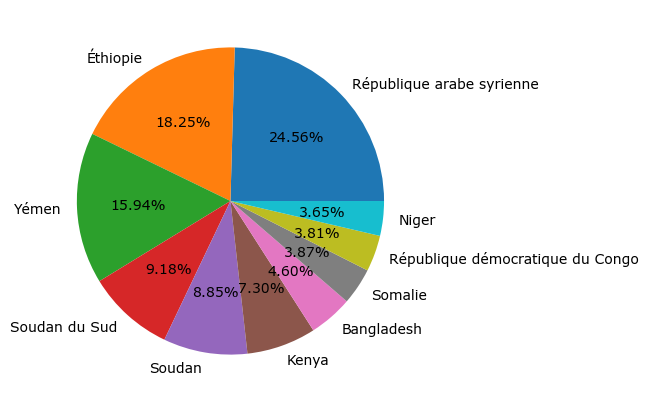

In [64]:
import matplotlib.pyplot as plt
plt.pie(x=Liste_10pays_le_plus_aidé_since_2013['Valeur'],labels=Liste_10pays_le_plus_aidé_since_2013['Zone'],autopct='%2.2f%%')

C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\2000790552.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels([0,250,500,750,1000,1250,1500,1750])


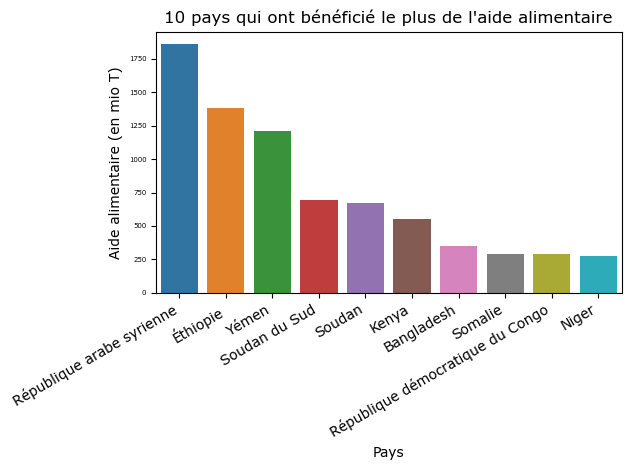

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt
g=sns.barplot(data = Liste_10pays_le_plus_aidé_since_2013,x='Zone',y='Valeur')
g.set_title("10 pays qui ont bénéficié le plus de l'aide alimentaire")
g.set_yticklabels([0,250,500,750,1000,1250,1500,1750])
g.set_ylabel("Aide alimentaire (en mio T)")
g.set_xlabel("Pays")
plt.rcParams.update({'xtick.labelsize':10,'ytick.labelsize':5})
plt.xticks(rotation=30,ha='right')
plt.ylabel= ("Aide alimentaire")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [68]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
Data_2013_2016_Aide_alimentaire = Aide_alimentaire[['Zone','Année','Valeur']]
Data_regroupé_enzoneetannée = Data_2013_2016_Aide_alimentaire.groupby(['Zone','Année']).agg({'Valeur':'sum'})
Data_regroupé_enzoneetannée = Data_regroupé_enzoneetannée.reset_index()
display(Data_regroupé_enzoneetannée)

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [69]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
Data_top5_aide = Data_regroupé_enzoneetannée.pivot_table(index='Zone',values='Valeur',aggfunc='sum').sort_values(['Valeur'],ascending=[False]).head(5)
Data_top5_aide = Data_top5_aide.reset_index()
display(Data_top5_aide)

Liste_pays_top5 = Data_top5_aide['Zone'].to_list()
display(Liste_pays_top5)

,Zone,Valeur
0,République arabe syrienne,1858943000
1,Éthiopie,1381294000
2,Yémen,1206484000
3,Soudan du Sud,695248000
4,Soudan,669784000


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [70]:
#On filtre sur le dataframe avec notre liste
Liste_5_pays_dateframe = Data_regroupé_enzoneetannée.loc[Data_regroupé_enzoneetannée['Zone'].isin(Liste_pays_top5)]
display(Liste_5_pays_dateframe)
Liste_5_pays_dateframe.dtypes
Liste_5_pays_dateframe['Année']=Liste_5_pays_dateframe['Année'].astype(object)
Liste_5_pays_dateframe.dtypes

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\1779708694.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Liste_5_pays_dateframe['Année']=Liste_5_pays_dateframe['Année'].astype(object)


Zone      object
Année     object
Valeur     int64
dtype: object

C:\Users\726628\AppData\Local\anaconda3\Nouveau dossier\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\726628\AppData\Local\anaconda3\Nouveau dossier\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\91264608.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0,2013,"",2014,"",2015,"",2016])
C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\91264608.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

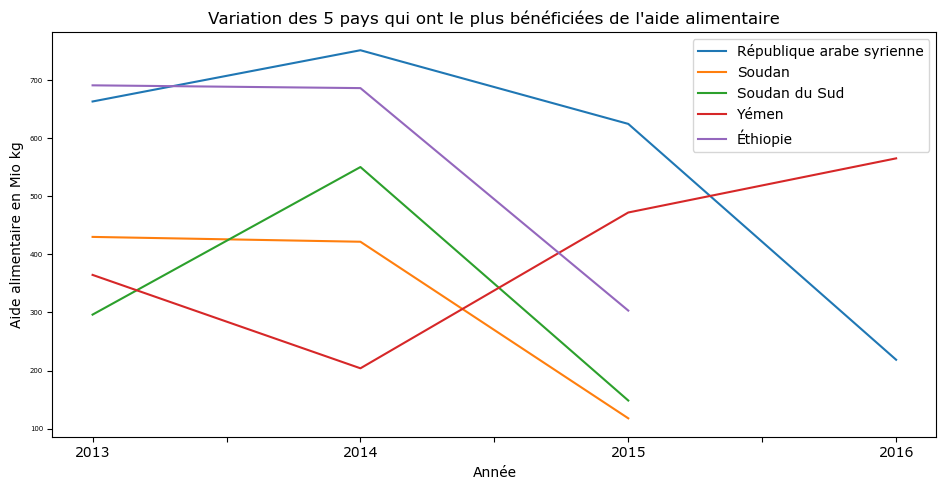

In [109]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
ax=sns.lineplot(Liste_5_pays_dateframe, x='Année', y='Valeur',errorbar=None, estimator=np.mean, hue='Zone')
ax.set_title("Variation des 5 pays qui ont le plus bénéficiées de l'aide alimentaire")
ax.set_xlabel("Année")
ax.set_ylabel("Aide alimentaire en Mio kg")
ax.set_xticklabels([0,2013,"",2014,"",2015,"",2016])
ax.set_yticklabels([0,100,200,300,400,500,600,700])
plt.legend(bbox_to_anchor=(1,1))
plt.show()


In [ ]:
# Affichage des pays avec l'aide alimentaire par année
Data_regroupé_enzoneetannée = Data_2013_2016_Aide_alimentaire.groupby(['Zone','Année']).agg({'Valeur':'sum'})
display(Data_regroupé_enzoneetannée)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [159]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_kcal_hab = Personne_nourries.groupby(['Zone']).agg({'Disponibilité alimentaire (Kcal/personne/jour)':'sum'})
display(dispo_kcal_hab)
dispo_kcal_hab['Proportion_dispo_Kcal_habitant']= round((dispo_kcal_hab/Besoin_Kcal_jour_pers),2)
display(dispo_kcal_hab)

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Afghanistan,2087.0
Afrique du Sud,3020.0
Albanie,3188.0
Algérie,3293.0
Allemagne,3503.0
...,...
Émirats arabes unis,3275.0
Équateur,2346.0
États-Unis d'Amérique,3682.0


,Disponibilité alimentaire (Kcal/personne/jour),Proportion_dispo_Kcal_habitant
Zone,,
Afghanistan,2087.0,0.87
Afrique du Sud,3020.0,1.26
Albanie,3188.0,1.33
Algérie,3293.0,1.37
Allemagne,3503.0,1.46
...,...,...
Émirats arabes unis,3275.0,1.36
Équateur,2346.0,0.98
États-Unis d'Amérique,3682.0,1.53


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Proportion_dispo_Kcal_habitant
0,République centrafricaine,1879.0,0.78
1,Zambie,1924.0,0.80
2,Madagascar,2056.0,0.86
3,Afghanistan,2087.0,0.87
4,Haïti,2089.0,0.87
5,République populaire démocratique de Corée,2093.0,0.87
6,Zimbabwe,2113.0,0.88
7,Tchad,2109.0,0.88
8,Éthiopie,2129.0,0.89
9,Ouganda,2126.0,0.89


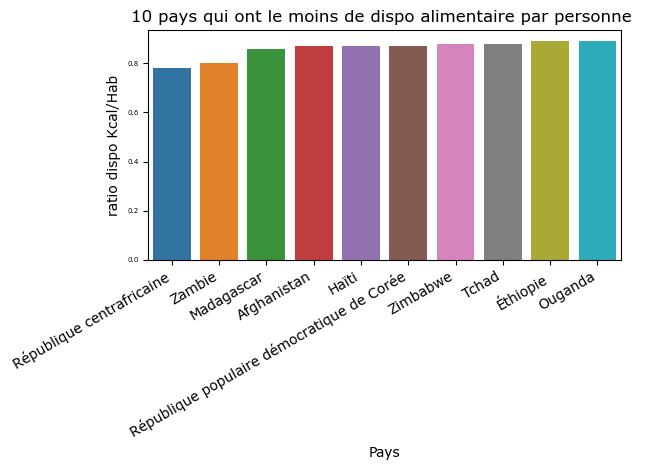

In [161]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
Pays_dispo_alim_lesplusfaibles_par_pers = dispo_kcal_hab.sort_values(['Proportion_dispo_Kcal_habitant'],ascending=[True]).head(10)
Pays_dispo_alim_lesplusfaibles_par_pers = Pays_dispo_alim_lesplusfaibles_par_pers.reset_index()
display(Pays_dispo_alim_lesplusfaibles_par_pers)
h=sns.barplot(data = Pays_dispo_alim_lesplusfaibles_par_pers,x='Zone',y='Proportion_dispo_Kcal_habitant')
h.set_title("10 pays qui ont le moins de dispo alimentaire par personne ")
h.set_xlabel("Pays")
h.set_ylabel("ratio dispo Kcal/Hab")
plt.rcParams.update({'xtick.labelsize':10,'ytick.labelsize':5})
plt.xticks(rotation=30,ha='right')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Proportion_dispo_Kcal_habitant
0,Autriche,3770.0,1.57
1,Belgique,3737.0,1.56
2,Turquie,3708.0,1.54
3,États-Unis d'Amérique,3682.0,1.53
4,Israël,3610.0,1.50
5,Irlande,3602.0,1.50
6,Italie,3578.0,1.49
7,Luxembourg,3540.0,1.48
8,Égypte,3518.0,1.47
9,Allemagne,3503.0,1.46


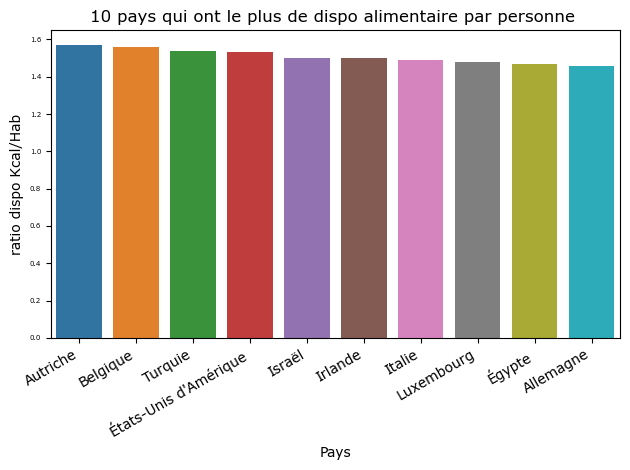

In [157]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
Pays_dispo_alim_lesplusfort = dispo_kcal_hab.sort_values(['Disponibilité alimentaire (Kcal/personne/jour)'],ascending=[False]).head(10)
Pays_dispo_alim_lesplusfort = Pays_dispo_alim_lesplusfort.reset_index()
display(Pays_dispo_alim_lesplusfort)
h=sns.barplot(data = Pays_dispo_alim_lesplusfort,x='Zone',y='Proportion_dispo_Kcal_habitant')
h.set_title("10 pays qui ont le plus de dispo alimentaire par personne ")
h.set_xlabel("Pays")
h.set_ylabel("ratio dispo Kcal/Hab")
plt.rcParams.update({'xtick.labelsize':10,'ytick.labelsize':5})
plt.xticks(rotation=30,ha='right')
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [123]:
#création d'un dataframe avec uniquement la Thaïlande 
Data_Thailande = Personne_nourries.loc[Personne_nourries['Zone']=='Thaïlande']
display(Data_Thailande)

,Zone,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
14116,Thaïlande,69209810.0,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000.0,5000.0,33000.0,75000.0,0.0,45000.0,0.0,0.0,0.0
14117,Thaïlande,69209810.0,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000.0,6000.0,2000.0,6000.0,0.0,12000.0,0.0,2000.0,0.0
14118,Thaïlande,69209810.0,"Alcool, non Comestible",vegetale,0.0,358000.0,0.0,0.00,0.00,0.00,358000.0,110000.0,21000.0,0.0,0.0,447000.0,0.0,0.0,0.0
14119,Thaïlande,69209810.0,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000.0,7000.0,19000.0,12000.0,0.0,0.0,0.0,0.0,0.0
14120,Thaïlande,69209810.0,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000.0,1449000.0,9000.0,671000.0,110000.0,2209000.0,0.0,0.0,13000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14206,Thaïlande,69209810.0,Viande de Suides,animale,0.0,0.0,124.0,13.00,11.83,3.92,871000.0,22000.0,1000.0,871000.0,0.0,891000.0,0.0,0.0,0.0
14207,Thaïlande,69209810.0,Viande de Volailles,animale,0.0,0.0,52.0,13.69,3.62,4.49,945000.0,536000.0,11000.0,917000.0,28000.0,1470000.0,0.0,0.0,0.0
14208,Thaïlande,69209810.0,"Viande, Autre",animale,0.0,0.0,0.0,0.03,0.01,0.02,-92000.0,96000.0,4000.0,2000.0,0.0,0.0,0.0,0.0,0.0
14209,Thaïlande,69209810.0,Vin,vegetale,0.0,0.0,0.0,0.12,0.00,0.00,8000.0,8000.0,16000.0,8000.0,0.0,0.0,0.0,0.0,0.0


In [166]:
#Calcul de la sous nutrition en Thaïlande
Data_sous_nutrition_Thailande = Data_nutrition_2017.loc[Data_nutrition_2017['Zone']=='Thaïlande']
Data_sous_nutrition_Thailande = Data_sous_nutrition_Thailande.reset_index()
print(Data_sous_nutrition_Thailande)
Part_ss_nutr_sur_pop_thai = round(((Data_sous_nutrition_Thailande)['sous_nutrition']/(Data_sous_nutrition_Thailande)['Population'])*100,2)
print("Le proportion de sous nutrition en thailande est de", Part_ss_nutr_sur_pop_thai)

   index       Zone  Population  sous_nutrition
0    185  Thaïlande  69209810.0       6200000.0
Le proportion de sous nutrition en thailande est de 0    8.96
dtype: float64


In [245]:
# On calcule la proportion exportée en fonction de la proportion produite
Manioc_Thai = Data_Thailande.loc[Data_Thailande['Produit']=='Manioc']
display(Manioc_Thai)
Ratio_prod_export_manioc = round(((Manioc_Thai)['Exportations - Quantité']/(Manioc_Thai)['Production'])*100,2)
print("le ration export/prod est",Ratio_prod_export_manioc)

,Zone,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
14166,Thaïlande,69209810.0,Manioc,vegetale,1800000.0,2081000.0,40.0,13.0,0.05,0.14,6264000.0,25214000.0,1250000.0,871000.0,1511000.0,30228000.0,0.0,0.0,0.0


le ration export/prod est 14166    83.41
dtype: float64


In [137]:
# Quelle est la disponibilité par habitant pour la Thaïlande ? Disponibilité alimentaire (Kcal/personne/jour)?
Dispo_Thailande_hab = Data_Thailande.agg({'Disponibilité alimentaire (Kcal/personne/jour)':'sum'})
print("la disponibilité intérieur en Thailande est de",Dispo_Thailande_hab)

la disponibilité intérieur en Thailande est de Disponibilité alimentaire (Kcal/personne/jour)    2785.0
dtype: float64


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [272]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être 
#le plus en difficulté au niveau alimentaire"

In [172]:
display(Sous_nutrition)
display(Liste_pays_top5)
Pays_ayant_benef_le_plus_daide_vs_sous_nutrition = Sous_nutrition.loc[Sous_nutrition['Zone'].isin(Liste_pays_top5)]
Pays_ayant_benef_le_plus_daide_vs_sous_nutrition = Pays_ayant_benef_le_plus_daide_vs_sous_nutrition.reset_index()
display(Pays_ayant_benef_le_plus_daide_vs_sous_nutrition)

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0
...,...,...,...
1213,Zimbabwe,2013-2015,0.0
1214,Zimbabwe,2014-2016,0.0
1215,Zimbabwe,2015-2017,0.0
1216,Zimbabwe,2016-2018,0.0


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

,index,Zone,Année,sous_nutrition
0,366,Éthiopie,2012-2014,26200000.0
1,367,Éthiopie,2013-2015,24300000.0
2,368,Éthiopie,2014-2016,21700000.0
3,369,Éthiopie,2015-2017,21300000.0
4,370,Éthiopie,2016-2018,21100000.0
5,371,Éthiopie,2017-2019,21500000.0
6,900,République arabe syrienne,2012-2014,0.0
7,901,République arabe syrienne,2013-2015,0.0
8,902,République arabe syrienne,2014-2016,0.0
9,903,République arabe syrienne,2015-2017,0.0


C:\Users\726628\AppData\Local\anaconda3\Nouveau dossier\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\726628\AppData\Local\anaconda3\Nouveau dossier\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\573400423.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0,2012,2013,2014,2015,2016])
C:\Users\726628\AppData\Local\Temp\1\ipykernel_29368\573400423.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. aft

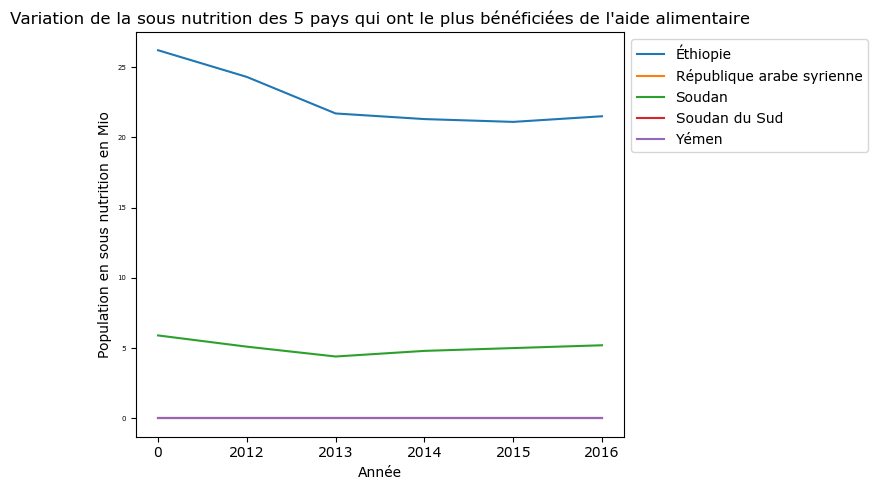

In [174]:
#étude des 5 pays ayant bénéficié le plus de l'aide alimentaire et leurs sous nutrition de 2012 à 2017
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
ax=sns.lineplot(Pays_ayant_benef_le_plus_daide_vs_sous_nutrition, x='Année', y='sous_nutrition',errorbar=None, estimator=np.mean, hue='Zone')
ax.set_title("Variation de la sous nutrition des 5 pays qui ont le plus bénéficiées de l'aide alimentaire")
ax.set_xlabel("Année")
ax.set_ylabel("Population en sous nutrition en Mio")
ax.set_xticklabels([0,2012,2013,2014,2015,2016])
ax.set_yticklabels([0,0,5,10,15,20,25])
plt.legend(bbox_to_anchor=(1,1))
plt.show()
